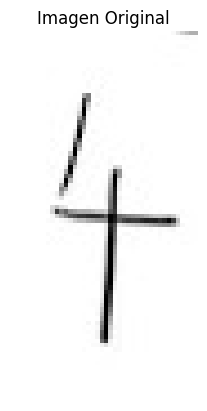

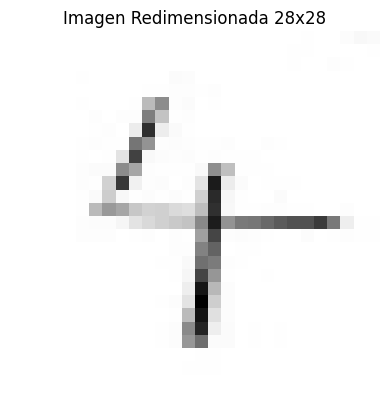

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9238 - loss: 0.2652
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9675 - loss: 0.1074
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9791 - loss: 0.0702
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9850 - loss: 0.0510
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9886 - loss: 0.0383
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9791 - loss: 0.0638
Precisión en test: 0.9790999889373779
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Probabilidades: [[0.00110782 0.03129825 0.00578364 0.00305618 0.45498148 0.00584626
  0.06866345 0.39706877 0.01067414 0.02152007]]
prediccion: 4


In [7]:
# importamos las librerias necesarias

from keras.datasets import mnist
from keras import layers, models
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import cv2

# importamos nuestra imagen y lo mostramos
img_original = cv2.imread("numero_4.jpeg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img_original, cmap='gray')
plt.title("Imagen Original")
plt.axis("off")
plt.show()

# redimensionamos a 28x28 y mostramos
img_resized = cv2.resize(img_original, (28, 28))

plt.imshow(img_resized, cmap='gray')
plt.title("Imagen Redimensionada 28x28")
plt.axis("off")
plt.show()


img = 255 - img_resized
img = img.astype('float32') / 255
img = img.reshape(1, 28*28)


# set de datos
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

# creaos un modelos de datos
model = models.Sequential()
model.add(layers.Dense(512, activation='relu', input_shape=(28*28,)))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# limpieza de datos
x_train = train_data.reshape((60000, 28*28))
x_train = x_train.astype('float32') / 255

x_test = test_data.reshape((10000, 28*28))
x_test = x_test.astype('float32') / 255

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

# entrenamos el modelo
model.fit(x_train, y_train, epochs=5, batch_size=128)


test_loss, test_acc = model.evaluate(x_test, y_test)
print("Precisión en test:", test_acc)


prediction = model.predict(img)

print("Probabilidades:", prediction)
print("prediccion:", np.argmax(prediction))